# Deep-feature MLP baseline (CNN-equivalent on pooled embeddings)

Sanity baseline: discard the graph entirely, take the mean over the 4096 nodes of the multilevel deep features, feed the resulting `(D,)` vector to a small MLP. If this matches/beats SGCN-deep or GAT, the graph structure isn't contributing — useful finding either way.

Hierarchy + tail-merge auto-enabled for L2/L3.

In [1]:
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

from fgvd_utils import ExperimentConfig, run_experiment

CKPT_ROOT = Path('checkpoints')
PLOT_ROOT = Path('plots')

## L1 — vehicle type


=== CNN | L1 | deep | hierarchical=False | tail_min=None ===
Samples: train=15702 val=3850 test=4890 | classes=7
Epoch 001 | train_acc=0.8098 val_acc=0.8423 | train_loss=0.9147 val_loss=0.8225
Epoch 005 | train_acc=0.8700 val_acc=0.8566 | train_loss=0.7338 val_loss=0.7720
Epoch 010 | train_acc=0.8815 val_acc=0.8655 | train_loss=0.6970 val_loss=0.7536
Epoch 015 | train_acc=0.8868 val_acc=0.8644 | train_loss=0.6782 val_loss=0.7423
Epoch 020 | train_acc=0.8947 val_acc=0.8675 | train_loss=0.6621 val_loss=0.7479
Epoch 025 | train_acc=0.8996 val_acc=0.8649 | train_loss=0.6473 val_loss=0.7420
Epoch 030 | train_acc=0.9028 val_acc=0.8699 | train_loss=0.6393 val_loss=0.7415
Epoch 035 | train_acc=0.9073 val_acc=0.8665 | train_loss=0.6287 val_loss=0.7501
Epoch 040 | train_acc=0.9105 val_acc=0.8657 | train_loss=0.6182 val_loss=0.7402
Epoch 045 | train_acc=0.9151 val_acc=0.8714 | train_loss=0.6073 val_loss=0.7353
Epoch 050 | train_acc=0.9189 val_acc=0.8691 | train_loss=0.5973 val_loss=0.7489

Test 

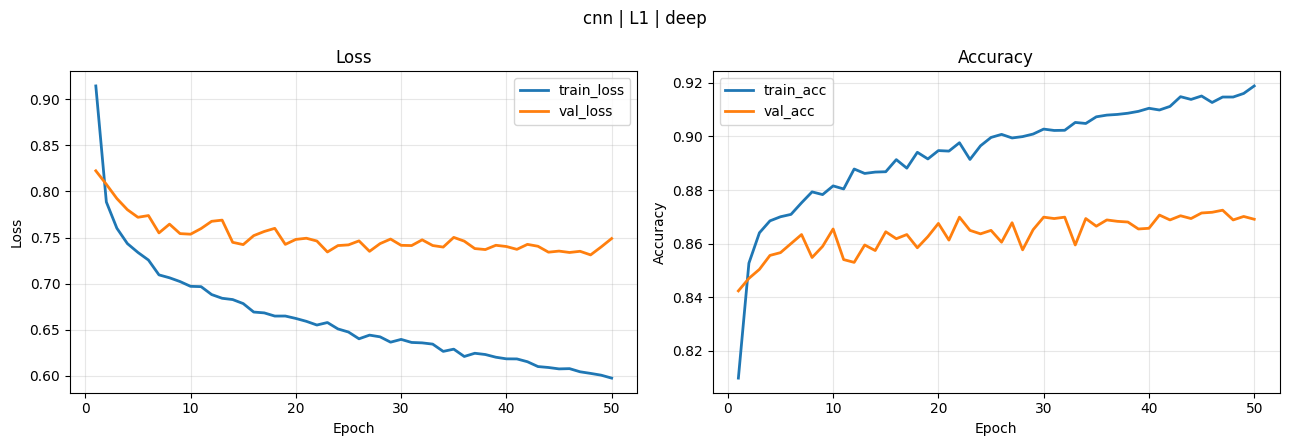

{'loss': 0.42995525320614775,
 'acc': 0.8685071574642127,
 'macro_f1': 0.7989129876021099,
 'weighted_f1': 0.8680334220906875,
 'top1_acc': 0.8685071574642127,
 'top3_acc': 0.9783231083844581,
 'top5_acc': 0.9948875255623721,
 'val_acc_best': 0.8724675324675325}

In [2]:
cfg_l1 = ExperimentConfig(
    method='cnn', level='L1', feature_source='deep',
    epochs=50, batch_size=128, lr=1e-3, weight_decay=1e-4,
    dropout=0.4,
    use_logit_adjustment=False,
)
out_l1 = run_experiment(cfg_l1, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l1['metrics']

## L2 — manufacturer

In [ ]:
cfg_l2 = ExperimentConfig(
    method='cnn', level='L2', feature_source='deep',
    epochs=80, batch_size=128, lr=1e-3, weight_decay=1e-4,
    dropout=0.5,
)
out_l2 = run_experiment(cfg_l2, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l2['metrics']


=== CNN | L2 | deep | hierarchical=True | tail_min=20 ===
Samples: train=15702 val=3850 test=4890 | classes=46
Tail-merge: kept 41/59 classes | coverage train=0.991 val=0.990 test=0.992
Epoch 001 | train_acc=0.0618 val_acc=0.0701 | train_loss=inf val_loss=inf
Epoch 005 | train_acc=0.0490 val_acc=0.0906 | train_loss=inf val_loss=inf


## L3 — model

In [ ]:
cfg_l3 = ExperimentConfig(
    method='cnn', level='L3', feature_source='deep',
    epochs=80, batch_size=128, lr=1e-3, weight_decay=1e-4,
    dropout=0.5,
)
out_l3 = run_experiment(cfg_l3, ckpt_root=CKPT_ROOT, plot_root=PLOT_ROOT)
out_l3['metrics']